### 1. Config + Imports

In [ ]:
from __future__ import annotations

import os
from collections import defaultdict

import numpy as np
import torch
import tqdm
import mlflow

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

from sydneymtl.datasets import SydneyBatch, SydneyDataset
from sydneymtl.log_ops import TRACKING_URI

BASE_PATH = "XXX"
FEATURE_DIR = os.path.join(BASE_PATH, "feature/hibouL")
CSV_PATH = os.path.join(BASE_PATH, "sydney_golden_set.csv")

TASKS = ["hp", "neut", "mono", "atrophy", "im"]
TASK_ORDER = ["hp", "im", "atrophy", "neut", "mono"]

MODEL_URI = "XXX"
DEVICE = "cuda:1"

OUT_PATH = "tsne_result_with_legend_box.png"
DPI = 300
RANDOM_STATE = 42

/data/home/wonchan/anaconda3/envs/seedp-api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def load_gt_dataset(feature_dir: str, csv_path: str, tasks: list[str]) -> SydneyDataset:
    batch = SydneyBatch.from_csv(
        feature_dir=feature_dir,
        csv_path=csv_path,
        tasknames=tasks,
        dry_run=False,
    )
    return SydneyDataset(batch)


def load_model(model_uri: str, device: str):
    mlflow.set_tracking_uri(TRACKING_URI)
    model = mlflow.pytorch.load_model(model_uri)
    model = model.to(device).eval()
    return model


@torch.no_grad()
def extract_task_slide_embeddings(
    model,
    dataset,
    tasks: list[str],
    device: str,
    num_workers: int = 2,
    prefetch_factor: int = 2,
):
    """
    Returns:
      embeddings[task] -> (n_slides, dim) list of np arrays
      labels[task]     -> (n_slides,) list of int labels
    """
    embeddings = defaultdict(list)
    labels = defaultdict(list)

    loader = DataLoader(
        dataset,
        shuffle=False,
        num_workers=num_workers,
        prefetch_factor=prefetch_factor,
    )

    for batch in tqdm.tqdm(loader, desc="Extracting embeddings"):
        feature, bag_label = batch  # feature: (1, N, D) if batch_size=1
        feature = feature.to(device).squeeze(0)  # (N, D)

        instance_features = model.adaptor(feature)  # (N, d')

        for task in tasks:
            attn_layer = model.attention_layers[task]
            attn = attn_layer(instance_features)  # (N,) expected

            # slide embedding: sum_i (attn_i * instance_feature_i)
            slide_emb = torch.einsum("i,ij->ij", attn, instance_features).sum(axis=0)  # (d',)

            embeddings[task].append(slide_emb.detach().cpu().numpy())
            labels[task].append(int(bag_label[task].item()))

    return embeddings, labels


gt_dataset = load_gt_dataset(FEATURE_DIR, CSV_PATH, TASKS)
model = load_model(MODEL_URI, DEVICE)

embeddings, labels = extract_task_slide_embeddings(
    model=model,
    dataset=gt_dataset,
    tasks=TASKS,
    device=DEVICE,
)

Loading SydneyBatch:   0%|          | 0/366 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 366/366 [00:27<00:00, 13.41it/s]


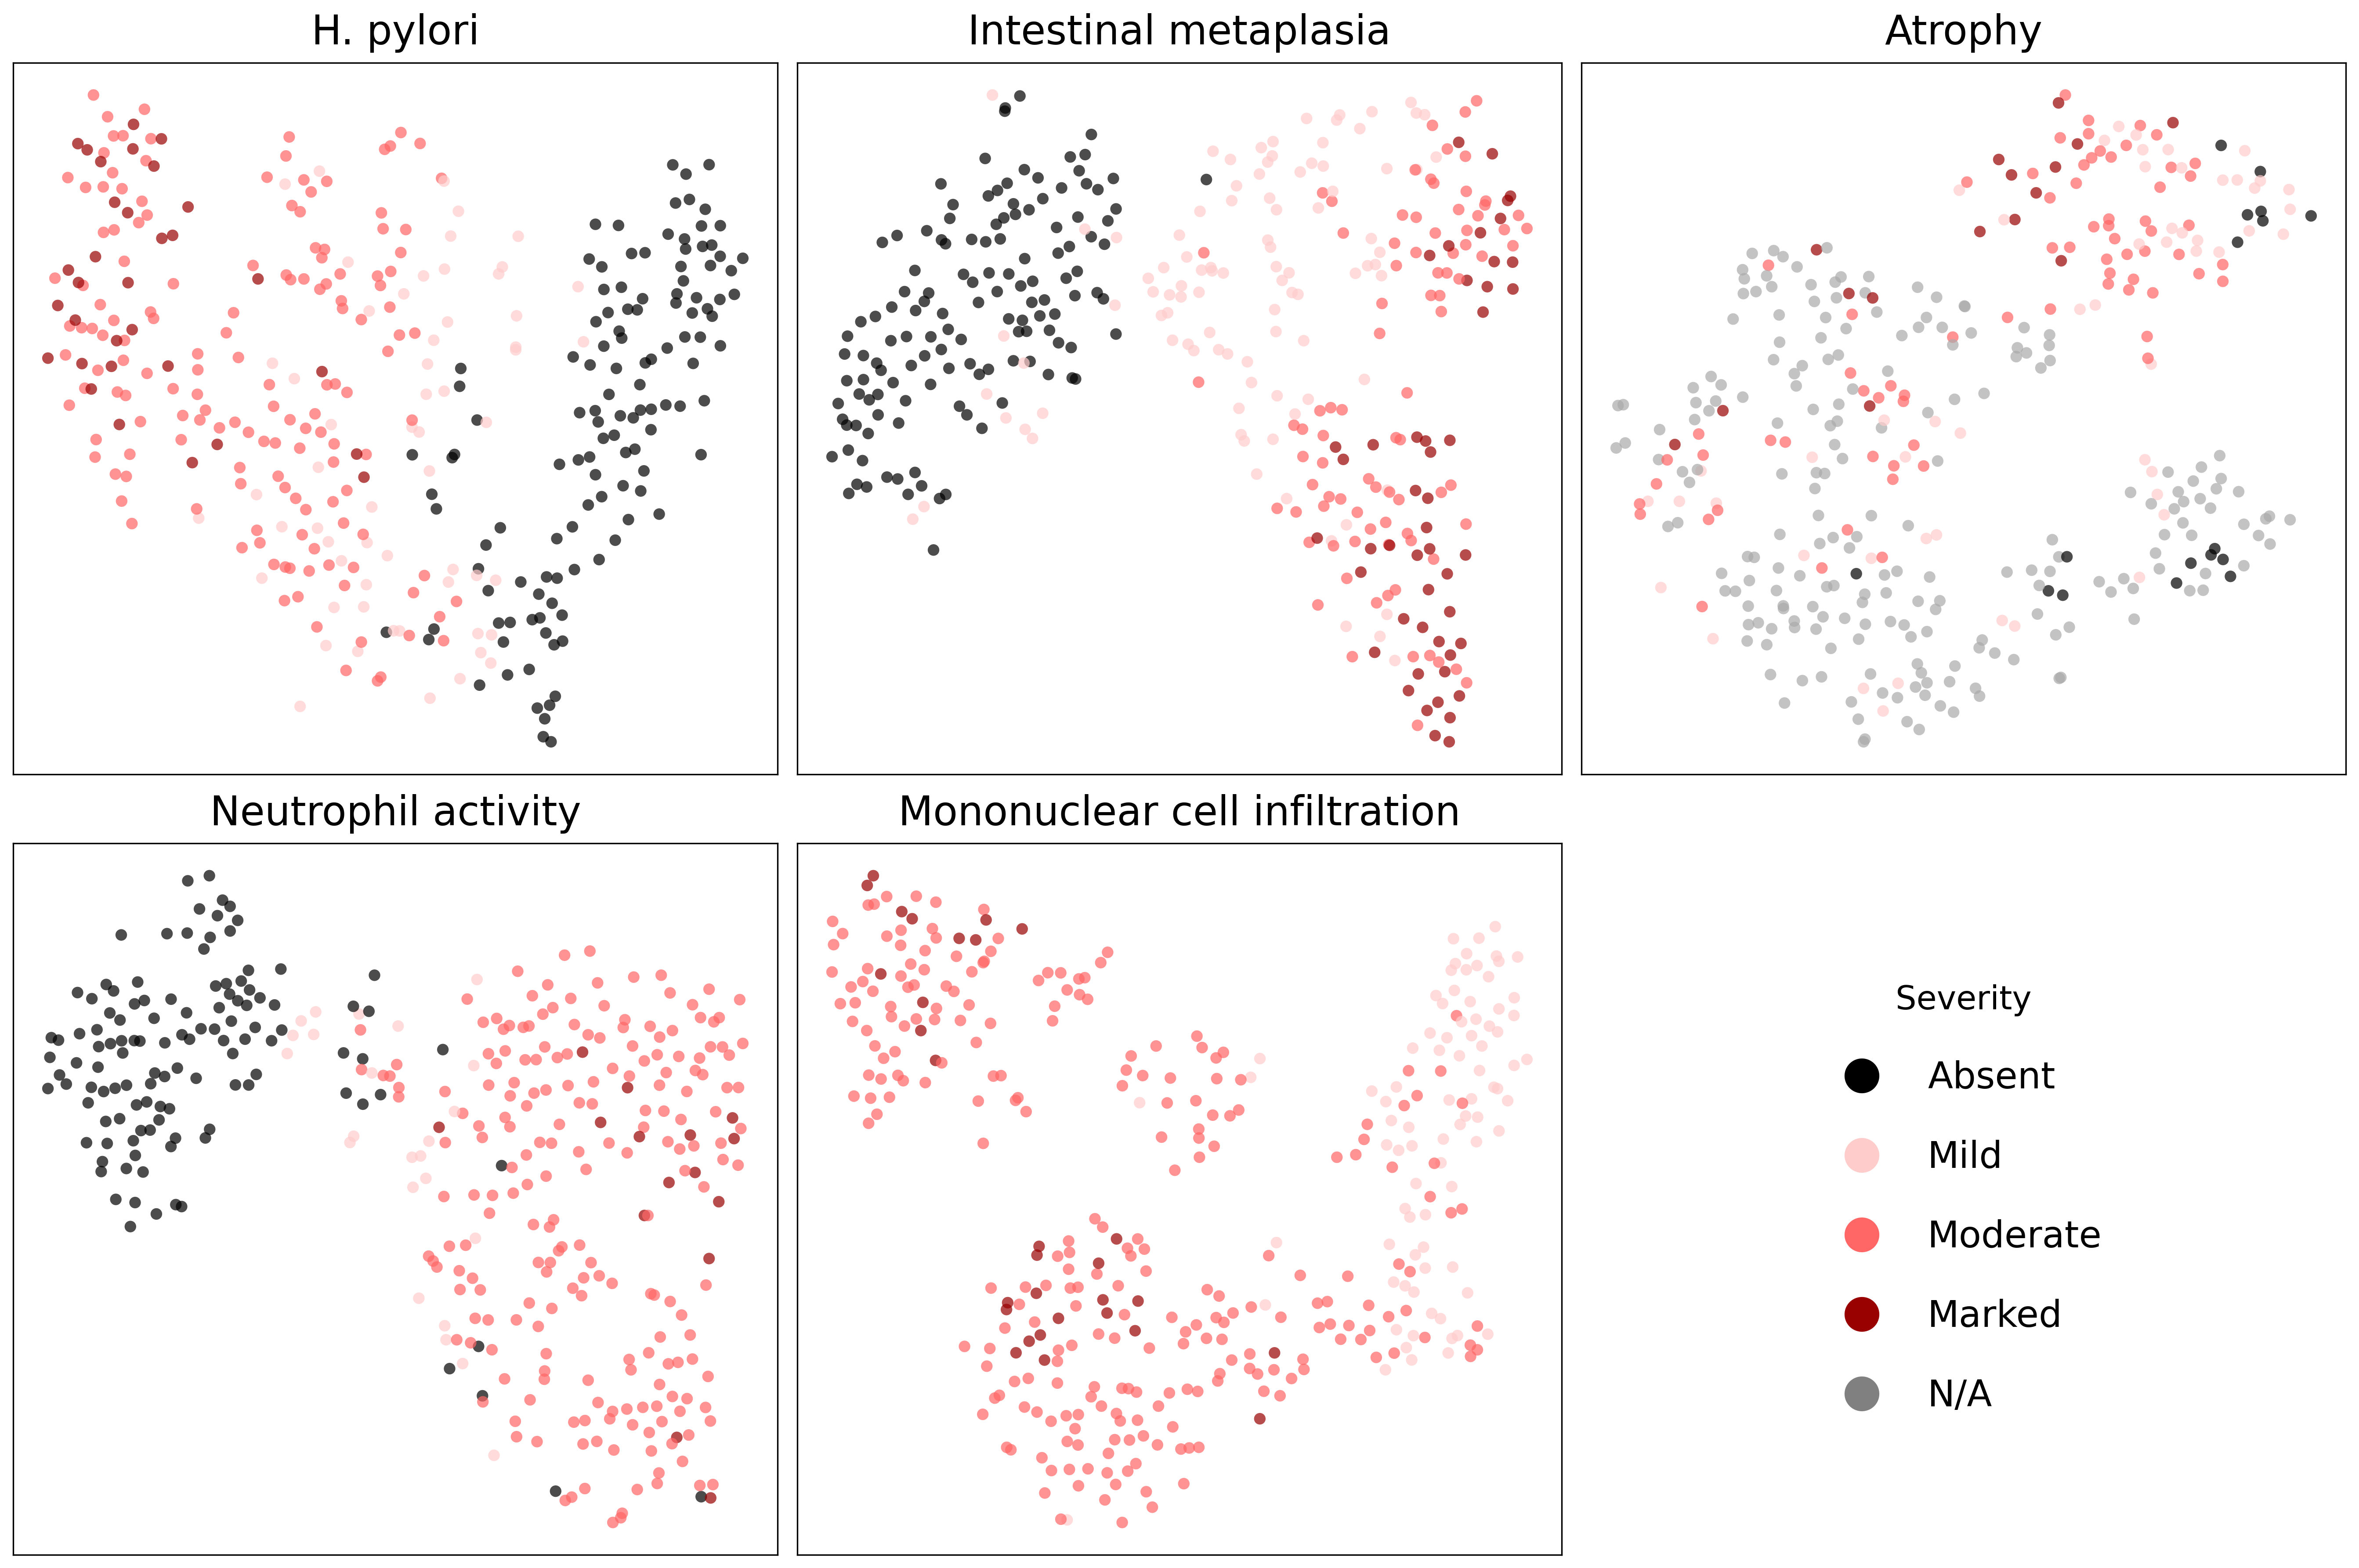

In [8]:
TITLE = {
    "hp": "H. pylori",
    "im": "Intestinal metaplasia",
    "mono": "Mononuclear cell infiltration",
    "neut": "Neutrophil activity",
    "atrophy": "Atrophy",
}


def color_for_label(lbl: int) -> str:
    # Absent/Mild/Moderate/Marked + N/A(9)
    if lbl == 0:
        return "#000000"
    if lbl == 1:
        return "#ffcccc"
    if lbl == 2:
        return "#ff6666"
    if lbl == 3:
        return "#990000"
    if lbl == 9:
        return "#808080"
    return "#aaaaaa"


def plot_tsne_grid(
    embeddings: dict,
    labels: dict,
    task_order: list[str],
    title_map: dict,
    out_path: str,
    dpi: int = 300,
    random_state: int = 42,
):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi=dpi)
    axes = axes.flatten()

    for i, task in enumerate(task_order):
        ax = axes[i]
        X = np.stack(embeddings[task])
        y = np.asarray(labels[task], dtype=int)

        perplexity = max(5, min(30, X.shape[0] - 1))
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            max_iter=1000,
            random_state=random_state,
            verbose=0,
        )
        X2 = tsne.fit_transform(X)
        c = np.array([color_for_label(int(v)) for v in y])

        ax.scatter(X2[:, 0], X2[:, 1], c=c, s=40, alpha=0.7, edgecolors="none")
        ax.set_title(title_map.get(task, task), fontsize=22, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # legend pane
    legend_ax = axes[5]
    legend_ax.axis("off")

    legend_elements = [
        Line2D([0], [0], marker="o", color="w", label="Absent",
               markerfacecolor=color_for_label(0), markersize=20),
        Line2D([0], [0], marker="o", color="w", label="Mild",
               markerfacecolor=color_for_label(1), markersize=20),
        Line2D([0], [0], marker="o", color="w", label="Moderate",
               markerfacecolor=color_for_label(2), markersize=20),
        Line2D([0], [0], marker="o", color="w", label="Marked",
               markerfacecolor=color_for_label(3), markersize=20),
        Line2D([0], [0], marker="o", color="w", label="N/A",
               markerfacecolor=color_for_label(9), markersize=20),
    ]

    legend_ax.legend(
        handles=legend_elements,
        loc="center",
        fontsize=20,
        title="Severity",
        title_fontsize=18,
        frameon=False,
        labelspacing=1.2,
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()


plot_tsne_grid(
    embeddings=embeddings,
    labels=labels,
    task_order=TASK_ORDER,
    title_map=TITLE,
    out_path=OUT_PATH,
    dpi=DPI,
    random_state=RANDOM_STATE,
)